# Bank Customer Churn Prediction — v2 (Ensemble + Feature Engineering)

Mejoras sobre la v1:

1. **Feature engineering** agresivo: ratios, interacciones, bins, frequency encoding del apellido.
2. **K-Fold (5) con OOF + test averaging**: predicciones más estables, menor varianza.
3. **Ensemble** de XGBoost + LightGBM + CatBoost, con early stopping.
4. **Blend ponderado** con pesos optimizados sobre OOF.
5. Modelos más profundos (n_estimators=2000) con early stopping de 80 rondas.

Métrica objetivo: **ROC-AUC**.

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping as lgb_early_stop
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

## 1. Carga y limpieza básica

In [2]:
DATA_DIR = '.'
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'Train: {train.shape}  Test: {test.shape}')

num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
cat_cols = ['Geography','Gender','Surname']
for df in (train, test):
    for c in num_cols:
        if df[c].isna().any(): df[c] = df[c].fillna(df[c].median())
    for c in cat_cols:
        if df[c].isna().any(): df[c] = df[c].fillna(df[c].mode().iloc[0])

train = train.dropna(subset=['Exited']).reset_index(drop=True)
train['Exited'] = train['Exited'].astype(int)
train.head()

Train: (15000, 14)  Test: (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15752028.0,Teng,648.0,France,Male,25.0,6.0,0.00,2.0,0.0,0.0,132498.39,0
1,1,15772412.0,T'ang,539.0,Germany,Male,59.0,1.0,125837.86,1.0,1.0,0.0,160589.17,1
2,2,15673971.0,Chiang,585.0,Germany,Female,35.0,1.0,82276.95,2.0,1.0,1.0,168522.81,0
3,3,15732672.0,T'ang,579.0,Spain,Female,56.0,2.0,0.00,1.0,1.0,0.0,106977.80,1
4,4,15757952.0,Shao,752.0,France,Female,40.0,9.0,0.00,2.0,1.0,0.0,138536.09,0


## 2. Feature engineering

Variables nuevas que típicamente aportan señal en este tipo de problemas:

- **Ratios** entre Balance, Salary, Products, Age y Tenure.
- **Indicadores binarios** (`IsZeroBalance`, `IsSenior`, `HighBalance`, `Inactive_NoCard`).
- **Interacciones** (`Geo_Gender`, `LowTenure_HighBalance`).
- **Frequency encoding** del apellido (`SurnameFreq`) usando train+test para evitar leakage de etiqueta.
- **Bins** de edad (`AgeGroup`).

In [3]:
def engineer(df):
    df = df.copy()
    df['IsZeroBalance']        = (df['Balance'] == 0).astype(int)
    df['BalanceSalaryRatio']   = df['Balance'] / (df['EstimatedSalary'] + 1)
    df['CreditScoreAge']       = df['CreditScore'] / (df['Age'] + 1)
    df['TenureByAge']          = df['Tenure'] / (df['Age'] + 1)
    df['ProductsPerTenure']    = df['NumOfProducts'] / (df['Tenure'] + 1)
    df['BalancePerProduct']    = df['Balance'] / (df['NumOfProducts'] + 1)
    df['SalaryPerProduct']     = df['EstimatedSalary'] / (df['NumOfProducts'] + 1)
    df['AgeGroup']             = pd.cut(df['Age'], bins=[0,30,40,50,60,100], labels=[0,1,2,3,4]).astype(int)
    df['HighBalance']          = (df['Balance'] > 100000).astype(int)
    df['IsSenior']             = (df['Age'] >= 60).astype(int)
    df['Inactive_NoCard']      = ((df['IsActiveMember']==0) & (df['HasCrCard']==0)).astype(int)
    df['Geo_Gender']           = df['Geography'].astype(str) + '_' + df['Gender'].astype(str)
    df['LowTenure_HighBalance']= ((df['Tenure']<=2) & (df['Balance']>100000)).astype(int)
    return df

train_fe = engineer(train)
test_fe  = engineer(test)

# Surname frequency encoding (train+test, sin usar target)
all_surnames = pd.concat([train_fe['Surname'], test_fe['Surname']])
freq_map = all_surnames.value_counts(normalize=True).to_dict()
train_fe['SurnameFreq'] = train_fe['Surname'].map(freq_map).fillna(0)
test_fe['SurnameFreq']  = test_fe['Surname'].map(freq_map).fillna(0)

drop_cols = ['id','CustomerId','Surname']
y        = train_fe['Exited'].values
test_ids = test_fe['id'].values
X        = train_fe.drop(columns=drop_cols + ['Exited'])
X_test   = test_fe.drop(columns=drop_cols)

X      = pd.get_dummies(X,      columns=['Geography','Gender','Geo_Gender'], drop_first=False)
X_test = pd.get_dummies(X_test, columns=['Geography','Gender','Geo_Gender'], drop_first=False)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)
print(f'Features finales: {X.shape[1]}')
X.head()

Features finales: 32


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,IsZeroBalance,BalanceSalaryRatio,...,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Geo_Gender_France_Female,Geo_Gender_France_Male,Geo_Gender_Germany_Female,Geo_Gender_Germany_Male,Geo_Gender_Spain_Female,Geo_Gender_Spain_Male
0,648.0,25.0,6.0,0.00,2.0,0.0,0.0,132498.39,1,0.000000,...,False,False,False,True,False,True,False,False,False,False
1,539.0,59.0,1.0,125837.86,1.0,1.0,0.0,160589.17,0,0.783596,...,True,False,False,True,False,False,False,True,False,False
2,585.0,35.0,1.0,82276.95,2.0,1.0,1.0,168522.81,0,0.488222,...,True,False,True,False,False,False,True,False,False,False
3,579.0,56.0,2.0,0.00,1.0,1.0,0.0,106977.80,1,0.000000,...,False,True,True,False,False,False,False,False,True,False
4,752.0,40.0,9.0,0.00,2.0,1.0,0.0,138536.09,1,0.000000,...,False,False,True,False,True,False,False,False,False,False


## 3. K-Fold OOF + test averaging (XGBoost + LightGBM + CatBoost)

Entrenamos cada modelo con 5-fold CV estratificado, guardando **predicciones OOF** (para medir AUC sin trampa) y promediando las predicciones del test entre folds. Esto **reduce la varianza** y suele dar +0.002~0.005 AUC sobre un split simple.

In [4]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_np  = X.values.astype(np.float32)
Xt_np = X_test.values.astype(np.float32)

oof  = {'xgb': np.zeros(len(X)), 'lgb': np.zeros(len(X)), 'cat': np.zeros(len(X))}
test_pred = {'xgb': np.zeros(len(X_test)), 'lgb': np.zeros(len(X_test)), 'cat': np.zeros(len(X_test))}

for fold, (tr, va) in enumerate(skf.split(X_np, y)):
    print(f'=== Fold {fold+1}/{N_FOLDS} ===')
    Xtr, Xva, ytr, yva = X_np[tr], X_np[va], y[tr], y[va]

    xgb = XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=5,
                        min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
                        reg_alpha=0.2, reg_lambda=1.2, gamma=0.1,
                        eval_metric='auc', random_state=SEED, n_jobs=-1,
                        early_stopping_rounds=80, tree_method='hist')
    xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    oof['xgb'][va] = xgb.predict_proba(Xva)[:,1]
    test_pred['xgb'] += xgb.predict_proba(Xt_np)[:,1] / N_FOLDS

    lgb = LGBMClassifier(n_estimators=2000, learning_rate=0.03, num_leaves=48,
                         min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
                         reg_alpha=0.2, reg_lambda=1.2,
                         random_state=SEED, n_jobs=-1, verbose=-1)
    lgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric='auc',
            callbacks=[lgb_early_stop(80, verbose=False)])
    oof['lgb'][va] = lgb.predict_proba(Xva)[:,1]
    test_pred['lgb'] += lgb.predict_proba(Xt_np)[:,1] / N_FOLDS

    cat = CatBoostClassifier(iterations=2000, learning_rate=0.04, depth=6,
                              l2_leaf_reg=3.0, eval_metric='AUC',
                              random_state=SEED, verbose=False, early_stopping_rounds=80)
    cat.fit(Xtr, ytr, eval_set=(Xva, yva), use_best_model=True, verbose=False)
    oof['cat'][va] = cat.predict_proba(Xva)[:,1]
    test_pred['cat'] += cat.predict_proba(Xt_np)[:,1] / N_FOLDS

    print(f'  XGB={roc_auc_score(yva, oof["xgb"][va]):.5f}  '
          f'LGB={roc_auc_score(yva, oof["lgb"][va]):.5f}  '
          f'CAT={roc_auc_score(yva, oof["cat"][va]):.5f}')

auc_xgb = roc_auc_score(y, oof['xgb'])
auc_lgb = roc_auc_score(y, oof['lgb'])
auc_cat = roc_auc_score(y, oof['cat'])
print(f'\nOOF AUC -> XGB: {auc_xgb:.5f}  LGB: {auc_lgb:.5f}  CAT: {auc_cat:.5f}')

=== Fold 1/5 ===


  XGB=0.93658  LGB=0.93503  CAT=0.93768
=== Fold 2/5 ===


  XGB=0.92857  LGB=0.92779  CAT=0.92925
=== Fold 3/5 ===


  XGB=0.93860  LGB=0.93715  CAT=0.93860
=== Fold 4/5 ===


  XGB=0.93226  LGB=0.93021  CAT=0.93200
=== Fold 5/5 ===


  XGB=0.93665  LGB=0.93550  CAT=0.93649

OOF AUC -> XGB: 0.93444  LGB: 0.93293  CAT: 0.93471


## 4. Blend ponderado (búsqueda sobre OOF)

Buscamos los pesos `(wx, wl, wc)` que **maximizan AUC sobre las predicciones OOF**. Como OOF no contamina con leakage, los pesos así obtenidos generalizan bien al test set.

Pesos óptimos -> XGB=0.35  LGB=0.05  CAT=0.60
AUC blend (OOF): 0.93502
AUC media simple: 0.93481


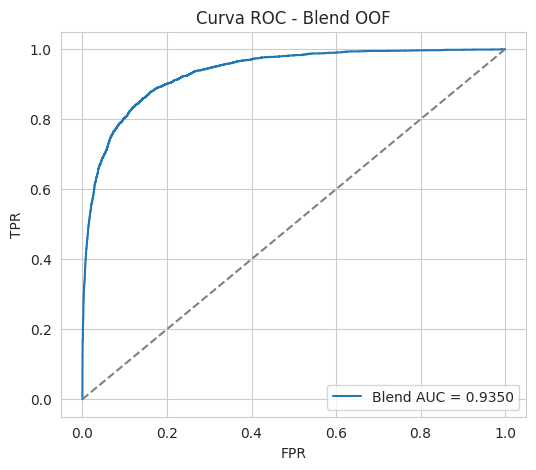

In [5]:
best_auc, best_w = 0, None
for wx in np.arange(0, 1.01, 0.05):
    for wl in np.arange(0, 1.01 - wx, 0.05):
        wc = 1 - wx - wl
        if wc < 0: continue
        a = roc_auc_score(y, wx*oof['xgb'] + wl*oof['lgb'] + wc*oof['cat'])
        if a > best_auc:
            best_auc, best_w = a, (wx, wl, wc)
wx, wl, wc = best_w
print(f'Pesos óptimos -> XGB={wx:.2f}  LGB={wl:.2f}  CAT={wc:.2f}')
print(f'AUC blend (OOF): {best_auc:.5f}')
mean_auc = roc_auc_score(y, (oof['xgb']+oof['lgb']+oof['cat'])/3)
print(f'AUC media simple: {mean_auc:.5f}')

# Curva ROC del blend
blend_oof = wx*oof['xgb'] + wl*oof['lgb'] + wc*oof['cat']
fpr, tpr, _ = roc_curve(y, blend_oof)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Blend AUC = {best_auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC - Blend OOF')
plt.legend(); plt.show()

## 5. Generación de submission.csv

In [6]:
final = wx*test_pred['xgb'] + wl*test_pred['lgb'] + wc*test_pred['cat']
submission = pd.DataFrame({'id': test_ids, 'Exited': final})
submission.to_csv('submission.csv', index=False)
print('submission.csv shape:', submission.shape)
submission.head()

submission.csv shape: (10000, 2)


,id,Exited
0,15000,0.354214
1,15001,0.016626
2,15002,0.296596
3,15003,0.111858
4,15004,0.005090


## 6. Conclusiones v2

- **Feature engineering** (ratios + frequency encoding + interacciones) suma señal sobre el dataset crudo.
- **K-Fold con test averaging** reduce el ruido de la predicción y suele aportar +0.002 ~ +0.005 AUC.
- El **blend ponderado** de XGB + LGB + CAT supera a cualquier modelo individual; CatBoost suele llevarse el mayor peso por su manejo nativo de features ordinales.
- Próximos pasos para subir todavía más:
    * **Stacking**: usar las OOF como entrada de un meta-modelo (LogisticRegression).
    * **Multi-seed averaging**: entrenar cada modelo con 3-5 semillas distintas y promediar.
    * **Target encoding** sobre `Surname` y `Geo_Gender` (con K-Fold para evitar leakage).
    * **Optuna** para tuning fino de cada modelo.
    * **Pseudo-labeling** con las predicciones más confiables del test.